### Monopólios Esportivos

**​A Pergunta:** Quais esportes são dominados por um único país?

​A Comparação: Analisar a porcentagem de medalhas de ouro ganhas por um único país em modalidades específicas.
​Ex: Tênis de Mesa (China), Basquete Masculino (EUA), Corridas de Longa Distância (Quênia/Etiópia), Tiro com Arco (Coreia do Sul).

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df_atleta = pd.read_csv('athlete_events_arrumado.csv', encoding='utf-8')
df_atleta['Medal'] = df_atleta['Medal'].fillna('0')
display(df_atleta.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,0


In [72]:
df_medalhas = df_atleta.groupby(['NOC', 'Sport'])['Medal'].value_counts().unstack(fill_value=0)

df_total = df_atleta.groupby(['NOC', 'Sport']).size().reset_index(name='Total_Atletas')

df_simples = pd.merge(df_total, df_medalhas, on=['NOC', 'Sport'])

display(df_simples.head())
display(df_total.head())
display(df_medalhas.head())

,NOC,Sport,Total_Atletas,0,Bronze,Gold,Silver
0,AFG,Athletics,22,22,0,0,0
1,AFG,Boxing,5,5,0,0,0
2,AFG,Football,11,11,0,0,0
3,AFG,Hockey,39,39,0,0,0
4,AFG,Judo,3,3,0,0,0


,NOC,Sport,Total_Atletas
0,AFG,Athletics,22
1,AFG,Boxing,5
2,AFG,Football,11
3,AFG,Hockey,39
4,AFG,Judo,3


Medal           0  Bronze  Gold  Silver
NOC Sport                              
AFG Athletics  22       0     0       0
    Boxing      5       0     0       0
    Football   11       0     0       0
    Hockey     39       0     0       0
    Judo        3       0     0       0

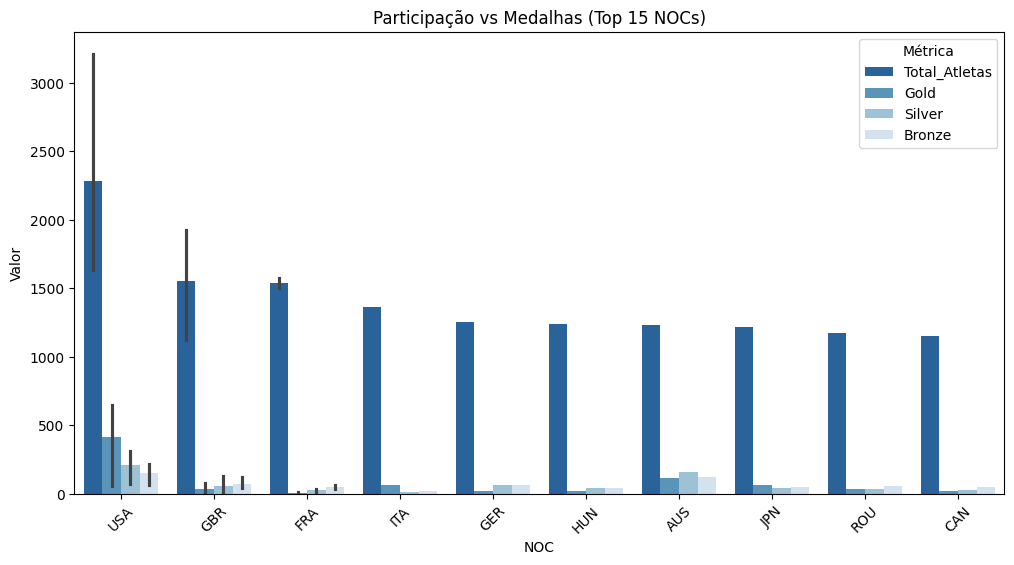

In [116]:
df_top = df_simples.nlargest(15, 'Total_Atletas')

df_plot = df_top.melt(id_vars=['NOC', 'Sport'], 
                      value_vars=['Total_Atletas', 'Gold', 'Silver', 'Bronze'],
                      var_name='Métrica', 
                      value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='NOC', y='Valor', hue='Métrica', palette='Blues_r') 
plt.xticks(rotation=45)
plt.title('Participação vs Medalhas (Top 15 NOCs)')
plt.show()

 e quais esportes tem mais medalhas por atleta por pais, e, e quais esportes tem mais medalhas por atleta por pais por ano por genero, e quais esportes tem mais medalhas por atleta por pais por ano por genero por tipo de medalha

In [74]:
# 1. Criar uma coluna com o Total de Medalhas Reais (Ouro + Prata + Bronze)
df_simples['Total_Medalhas'] = df_simples['Gold'] + df_simples['Silver'] + df_simples['Bronze']

# 2. Encontrar o esporte com mais medalhas para cada NOC
# Usamos o idxmax para pegar o índice da linha com o maior valor de medalhas por grupo
idx = df_simples.groupby('NOC')['Total_Medalhas'].idxmax()
df_destaque = df_simples.loc[idx, ['NOC', 'Sport', 'Total_Medalhas', 'Total_Atletas']]

# 3. Calcular a 'Taxa de Sucesso' desse esporte específico
df_destaque['Eficiencia_%'] = (df_destaque['Total_Medalhas'] / df_destaque['Total_Atletas'] * 100).round(2)

# Ordenar pelos países com mais medalhas no seu esporte principal
display(df_destaque.sort_values(by='Total_Medalhas', ascending=False).head(20))

,NOC,Sport,Total_Medalhas,Total_Atletas,Eficiencia_%
3134,USA,Athletics,1080,3211,33.63
169,AUS,Swimming,401,1235,32.47
1590,ITA,Fencing,359,736,48.78
1120,GBR,Athletics,338,2244,15.06
1045,FRA,Fencing,310,982,31.57
3096,URS,Gymnastics,288,797,36.14
2136,NED,Hockey,255,418,61.00
1390,HUN,Fencing,236,628,37.58
1231,GER,Rowing,236,526,44.87
509,CAN,Rowing,203,559,36.31


##### quais esportes tem mais medalhas?

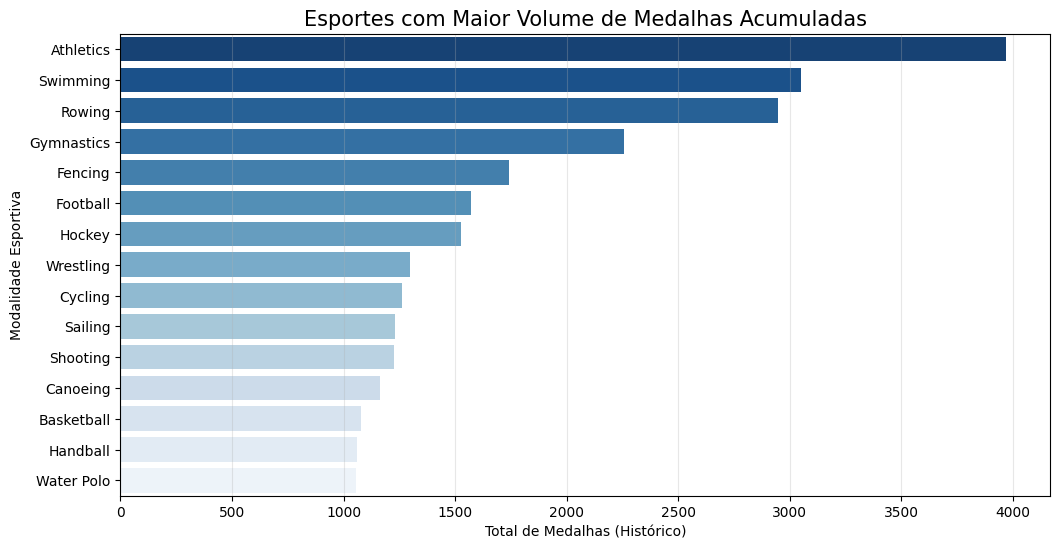

In [115]:
df_esportes_top = df_simples.groupby('Sport')['Total_Medalhas'].sum().nlargest(15).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_esportes_top, x='Total_Medalhas', y='Sport', hue='Sport', palette='Blues_r')

plt.title('Esportes com Maior Volume de Medalhas Acumuladas', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.grid(axis='x', alpha=0.3)
plt.show()

##### quais esportes tem mais atletas?

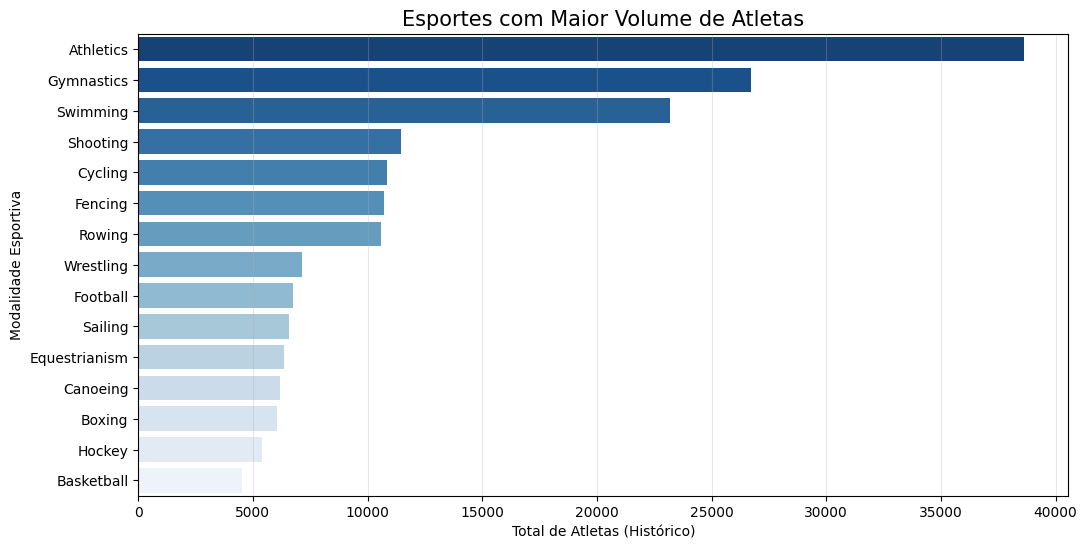

In [114]:
df_esportes_top = df_simples.groupby('Sport')['Total_Atletas'].sum().nlargest(15).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_esportes_top, x='Total_Atletas', y='Sport', hue='Sport', palette='Blues_r')

plt.title('Esportes com Maior Volume de Atletas', fontsize=15)
plt.xlabel('Total de Atletas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.grid(axis='x', alpha=0.3)
plt.show()

para cada pais analisa os esportes que mais se destacam,

,NOC,Sport,Total_Atletas,0,Bronze,Gold,Silver,Total_Medalhas
143,AUS,Archery,73,68,4,1,0,5
144,AUS,Art Competitions,3,3,0,0,0,0
145,AUS,Athletics,994,905,28,24,37,89
146,AUS,Badminton,57,57,0,0,0,0
147,AUS,Baseball,68,44,0,0,24,24


,NOC,Sport,Total_Medalhas
0,AUS,Archery,5
1,AUS,Art Competitions,0
2,AUS,Athletics,89
3,AUS,Badminton,0
4,AUS,Baseball,24


,NOC,Sport,Total_Medalhas
26,AUS,Swimming,401
60,CAN,Rowing,203
91,CHN,Gymnastics,109
125,FRA,Fencing,310
157,GBR,Athletics,338


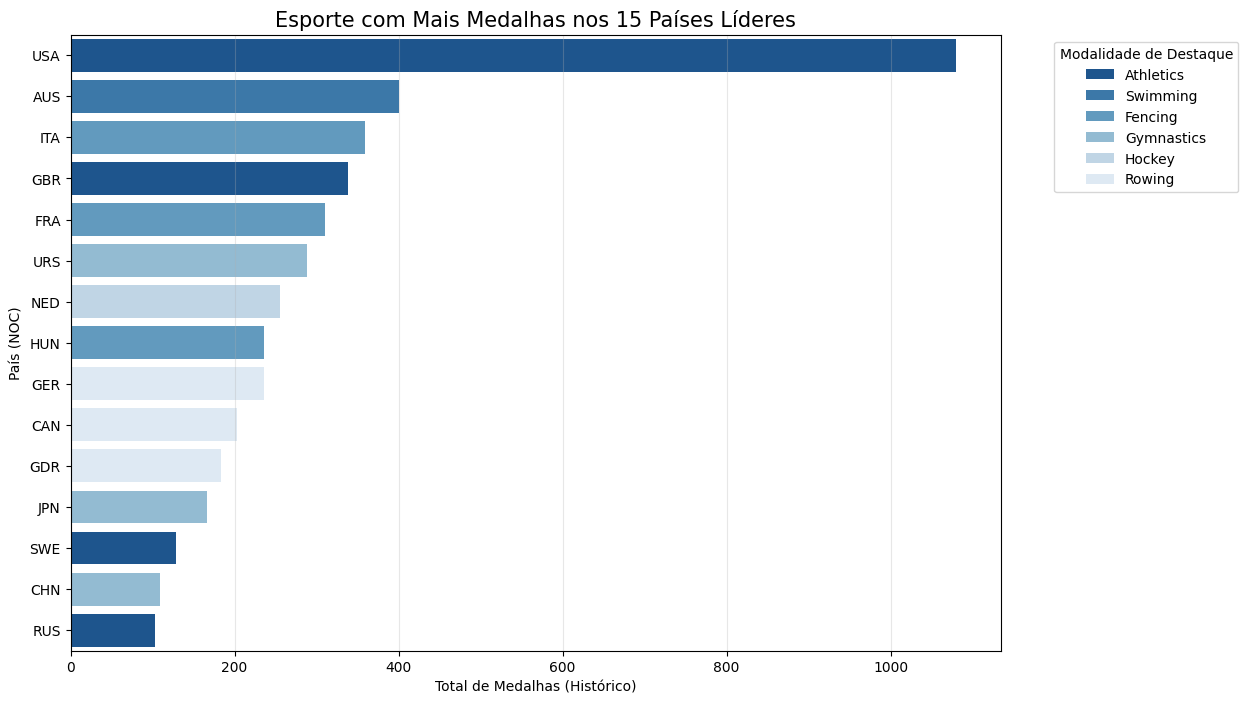

In [106]:
top_15_paises = df_simples.groupby('NOC')['Total_Medalhas'].sum().nlargest(15).index

df_filtrado = df_simples[df_simples['NOC'].isin(top_15_paises)]
display(df_filtrado.head())

df_esportes = df_filtrado.groupby(['NOC', 'Sport'])['Total_Medalhas'].sum().reset_index()
display(df_esportes.head())

df_final = df_esportes.sort_values(['NOC', 'Total_Medalhas'], ascending=[True, False]).drop_duplicates('NOC')
display(df_final.head())

plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_final.sort_values('Total_Medalhas', ascending=False), 
    x='Total_Medalhas', 
    y='NOC', 
    hue='Sport', 
    dodge=False, 
    palette='Blues_r' #Reds_r, blues_r, greens_r, Wistia, Greys_r
)

plt.title('Esporte com Mais Medalhas nos 15 Países Líderes', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('País (NOC)')
plt.legend(title='Modalidade de Destaque', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', alpha=0.3)
plt.show()

Analise do Brasil

C:\Users\maria\AppData\Local\Temp\ipykernel_17944\2305301270.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


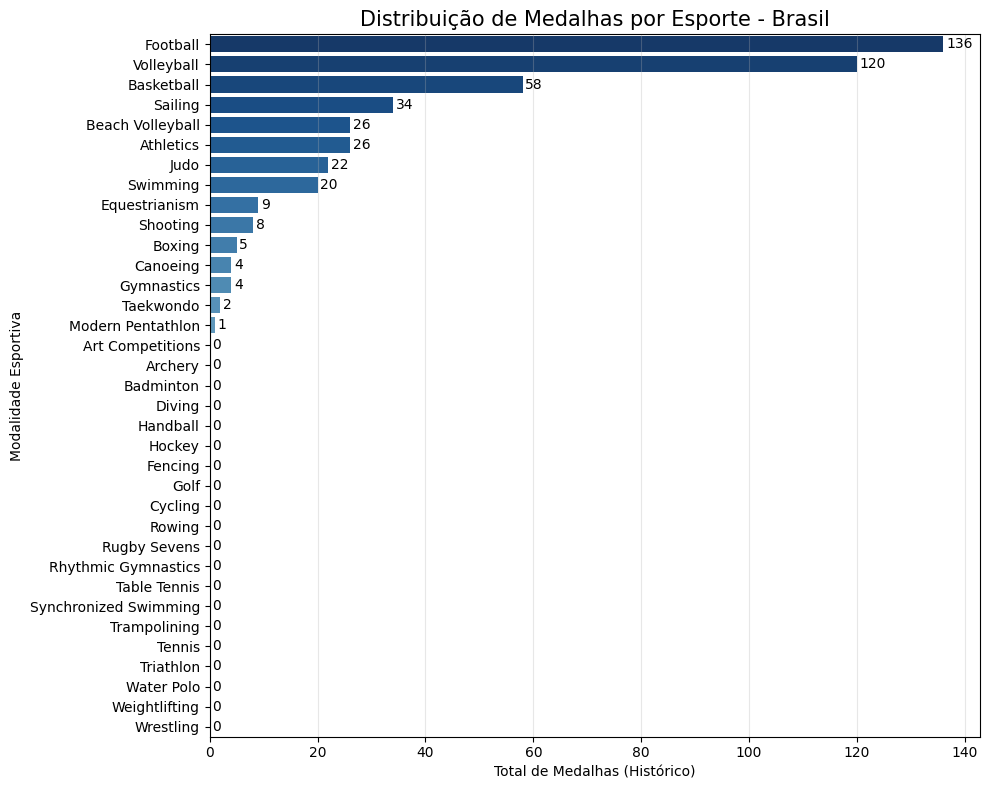

In [ ]:
df_brasil = df_simples[df_simples['NOC'] == 'BRA']

# 2. Agrupar por esporte e somar as medalhas
df_bra_esportes = df_brasil.groupby('Sport')['Total_Medalhas'].sum().sort_values(ascending=False).reset_index()

# 3. Criar o gráfico
plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_bra_esportes, 
    x='Total_Medalhas', 
    y='Sport', 
    palette='Blues_r' 
)

plt.title('Distribuição de Medalhas por Esporte - Brasil', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(df_bra_esportes['Total_Medalhas']):
    plt.text(v + 0.5, i, str(int(v)), color='black', va='center')

plt.tight_layout()
plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_17944\1983270463.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


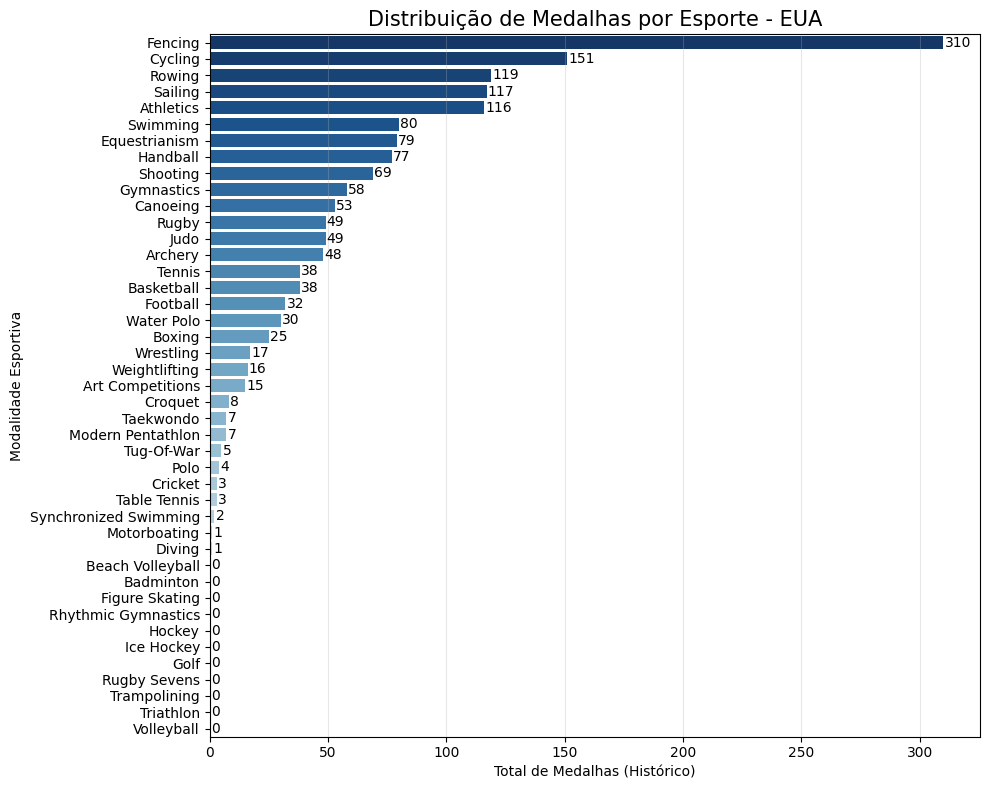

In [117]:
df_brasil = df_simples[df_simples['NOC'] == 'FRA']

# 2. Agrupar por esporte e somar as medalhas
df_bra_esportes = df_brasil.groupby('Sport')['Total_Medalhas'].sum().sort_values(ascending=False).reset_index()

# 3. Criar o gráfico
plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_bra_esportes, 
    x='Total_Medalhas', 
    y='Sport', 
    palette='Blues_r'
)

plt.title('Distribuição de Medalhas por Esporte - EUA', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(df_bra_esportes['Total_Medalhas']):
    plt.text(v + 0.5, i, str(int(v)), color='black', va='center')

plt.tight_layout()
plt.show()

In [120]:
display(df_simples.head())

,NOC,Sport,Total_Atletas,0,Bronze,Gold,Silver,Total_Medalhas
0,AFG,Athletics,22,22,0,0,0,0
1,AFG,Boxing,5,5,0,0,0,0
2,AFG,Football,11,11,0,0,0,0
3,AFG,Hockey,39,39,0,0,0,0
4,AFG,Judo,3,3,0,0,0,0


In [ ]:
# 1. Filtrar apenas medalhas de Ouro
df_ouros = df_simples[df_simples['Gold'] == 1]

# 2. Calcular o total de ouros por esporte (no mundo todo)
total_ouros_esporte = df_ouros.groupby('Sport')['Gold'].count()

# 3. Calcular ouros por País e Esporte
df_dominancia = df_ouros.groupby(['NOC', 'Sport'])['Medal'].count().reset_index()

# 4. Calcular a Porcentagem (%)
df_dominancia['Dominancia_%'] = df_dominancia.apply(
    lambda x: (x['Medal'] / total_ouros_esporte[x['Sport']]) * 100, axis=1
)

# 5. Filtrar para o Brasil (ou o país que desejar)
df_brasil_dom = df_dominancia[df_dominancia['NOC'] == 'BRA'].sort_values('Dominancia_%', ascending=False)

KeyError: 'Medal'

In [ ]:
plt.figure(figsize=(10, 8))

# Usando o degradê de cinzas/preto para um visual "Premium"
sns.barplot(
    data=df_brasil_dom.head(10), # Top 10 esportes dominados
    x='Dominancia_%', 
    y='Sport', 
    palette='Greys_r'
)

plt.title('Dominação Brasileira: % de Ouros Totais por Modalidade', fontsize=14, pad=20)
plt.xlabel('Porcentagem (%) de todas as medalhas de Ouro já entregues')
plt.ylabel('Modalidade')

# Adicionando o símbolo de % nas barras
for i, v in enumerate(df_brasil_dom.head(10)['Dominancia_%']):
    plt.text(v + 0.5, i, f'{v:.1f}%', color='black', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

#####  e quais esportes tem mais medalhas por atleta?